# A better GW source function, and the test that decides which one

The gravity-wave source parameterization in `BasicAna4GWP-fitting.ipynb` uses a
functional form that was, in Julio's words, cooked up:

$$\tau \;=\; y_0 \;+\; \underbrace{A\,\frac{(D/D_{\rm ref})^{a}}{1 + D/D_0}}_{\text{dynamical}}
\;+\; \underbrace{B\,(P/P_{\rm ref})^{b}\,(D/D_{\rm ref})^{c}}_{\text{convective}}$$

with $D$ = `tilt_zs`, $P$ = `precl`, $\tau$ = `epwp_zl`. Seven parameters, an
NNLS grid search then a log-space polish, and **r = 0.5784** — a Pearson
correlation in log space over 4.26M Southern-Hemisphere gridpoints.

This notebook asks whether [PySR](https://github.com/MilesCranmer/PySR) can do
better. Three findings, in the order they were forced on us:

1. **The form was never the problem.** Any $f(D, P)$ is capped at r ≈ 0.583, and
   the hand-built form is already at 0.578. Four independent methods agree. The
   ceiling lives in the *inputs*, not the algebra.
2. **Which predictors help depends on what you train on.** Fitted to the Southern
   Hemisphere alone, wind-based predictors buy a lot of SH skill and then fail in
   the NH — negative $R^2$, worse than predicting the mean.
3. **Training on both hemispheres fixes it.** The same wind predictors then
   become the best available, lifting NH r from 0.652 to 0.761. The apparent
   "these features don't transfer" was really "this model was fitted to one
   hemisphere's weather."

So the deliverable is a search over the wide predictor set, fitted globally —
with the tilt family as the conservative fallback that works either way.

**Environment.** JupyterHub kernel `PySR 1.5.10 (L96M2lines)`, or:

```bash
source /glade/u/apps/opt/miniforge/default/etc/profile.d/conda.sh
conda activate /glade/work/wchapman/conda-envs/L96M2lines
```

`gwsrc_data.npz` is built by `prep_gwsrc_data.py`, which applies Julio's
preprocessing (Gaussian smoothing $\sigma=(0,2,2)$, `MXDIS < 200 m`, lat bands)
and caches the result so nothing here needs netCDF4 or the 845 MB source file.

In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Julio's model and diagnostics, imported rather than reimplemented so the
# baseline number is his, not a lookalike.
sys.path.insert(0, '/glade/work/juliob/HiRes_ana_dev/Drivers/Analysis')
import source_fit_refvals as SF
import distro_fitting as DF

Z = np.load('gwsrc_data.npz')
get = lambda k, hemi='sh': Z[f'{k}_{hemi}'].astype(np.float64)
print(f"SH {Z['tidx_sh'].size:,} samples   NH {Z['tidx_nh'].size:,} samples")

SH 4,259,021 samples   NH 4,544,059 samples


## Plot style

Four categorical hues in fixed order, checked with the `dataviz` validator
(lightness band, chroma floor, CVD separation, contrast — all PASS in light and
dark). Grid and axes recessive; identity carried by the mark, not by coloured
text.

In [2]:
%matplotlib inline

BLUE   = '#4269D0'   # PySR, transfer-safe
AMBER  = '#C77B26'   # Julio's incumbent form
TEAL   = '#1A9E7F'   # PySR on (D,P), the control
PURPLE = '#9B4FBF'   # the SH-optimal but non-transferring set
INK, MUTED, FAINT = '#33322e', '#78766f', '#b3b0a6'

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10,
    'axes.edgecolor': '#c9c7c0', 'axes.labelcolor': INK,
    'axes.titlesize': 11, 'axes.titleweight': 'semibold', 'axes.titlecolor': INK,
    'axes.grid': True, 'axes.axisbelow': True,
    'grid.color': '#e6e4dd', 'grid.linewidth': 0.8,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'legend.frameon': False, 'figure.facecolor': 'white',
})

## 1. The number to beat

`source_fit_refvals.score` reports `r_full`, the correlation between
$\log(\text{pred})$ and $\log(\text{obs})$. Every number in this notebook uses
that same metric.

In [3]:
D, P, Y = get('tilt_zs'), get('precl'), get('epwp_zl')

# The 7-parameter NNLS grid solution, BasicAna4GWP-fitting.ipynb cell 28.
PAR_JULIO = dict(y0=0.0, A=0.05662744099311622, a=1.5, D0=4.754679577383344e-08,
                 B=0.002615114957098987, b=1.0999999999999999,
                 c=0.30000000000000004)

pred_julio = SF.source_model(D, P, **PAR_JULIO)
r_baseline = np.corrcoef(np.log(pred_julio), np.log(Y))[0, 1]
print(f'baseline r (log)  {r_baseline:.6f}')
print(f"Julio's notebook  0.5783581082929715")

baseline r (log)  0.578358
Julio's notebook  0.5783581082929715


## 2. Is the functional form the problem?

Before hunting for a better equation, ask whether one exists.
`distro_fitting.cell_spread` answers without reference to any functional form:
bin the sample in $(D, P)$ and split $\mathrm{var}(\log\tau)$ into between-cell
and within-cell parts.

Within-cell scatter is the spread among points with essentially *identical* $D$
and $P$. No function of $(D,P)$ can tell those points apart, so

$$r_{\max} = \sqrt{\frac{\sigma^2_{\rm between}}{\sigma^2_{\rm between} + \sigma^2_{\rm within}}}$$

caps every candidate equation at once. The obvious objection is bin resolution —
coarse cells misfile real structure as noise. That is testable: refine and watch
it converge.

In [4]:
ceil_rows = []
for n_d, n_p, mc in [(16, 12, 200), (24, 18, 200), (40, 30, 100),
                     (60, 45, 50), (80, 60, 25)]:
    _, _, de, pe = DF.bin_shape_1d(D, P, Y, n_d=n_d, n_p=n_p,
                                   min_count=mc, p_dry=0.9e-8)
    sp = DF.cell_spread(D, P, Y, de, pe, min_count=mc, p_dry=0.9e-8)
    ceil_rows.append((n_d * n_p, sp['r_ceiling']))

print(f'\n{"cells":>7}  {"ceiling on log-r":>16}')
for cells, c in ceil_rows:
    print(f'{cells:7d}  {c:16.4f}')
R_CEIL = ceil_rows[-1][1]

4259021 points (1937121 dry)


cells used:          208 of 208
within-cell  var:    0.8290  (log units)
between-cell var:    0.4145
explained fraction:  0.333
ceiling on log-r:    0.577
median 16–84 spread: 5.26x
4259021 points (1937121 dry)


cells used:          456 of 456
within-cell  var:    0.8256  (log units)
between-cell var:    0.4179
explained fraction:  0.336
ceiling on log-r:    0.580
median 16–84 spread: 5.20x
4259021 points (1937121 dry)


cells used:          1239 of 1240
within-cell  var:    0.8230  (log units)
between-cell var:    0.4205
explained fraction:  0.338
ceiling on log-r:    0.581
median 16–84 spread: 5.16x
4259021 points (1937121 dry)


cells used:          2756 of 2760
within-cell  var:    0.8217  (log units)
between-cell var:    0.4218
explained fraction:  0.339
ceiling on log-r:    0.582
median 16–84 spread: 5.15x
4259021 points (1937121 dry)


cells used:          4874 of 4880
within-cell  var:    0.8208  (log units)
between-cell var:    0.4227
explained fraction:  0.340
ceiling on log-r:    0.583
median 16–84 spread: 5.10x

  cells  ceiling on log-r
    192            0.5774
    432            0.5797
   1200            0.5815
   2700            0.5824
   4800            0.5831


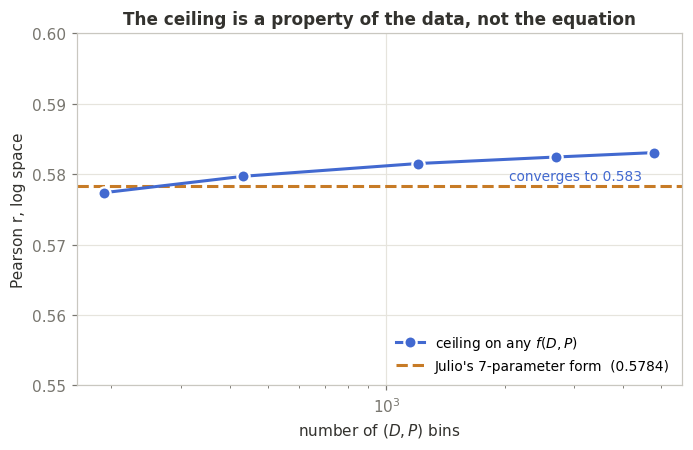

In [5]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
cells = [c for c, _ in ceil_rows]
ceils = [c for _, c in ceil_rows]

ax.plot(cells, ceils, '-o', color=BLUE, lw=2, ms=8, mfc=BLUE, mec='white',
        mew=1.5, zorder=3, label='ceiling on any $f(D,P)$')
ax.axhline(r_baseline, color=AMBER, lw=2, ls='--', zorder=2,
           label=f"Julio's 7-parameter form  ({r_baseline:.4f})")
ax.annotate(f'converges to {ceils[-1]:.3f}', xy=(cells[-1], ceils[-1]),
            xytext=(-8, -18), textcoords='offset points', color=BLUE,
            ha='right', fontsize=9)
ax.set(xscale='log', xlabel='number of $(D,P)$ bins',
       ylabel='Pearson r, log space', ylim=(0.55, 0.60),
       title='The ceiling is a property of the data, not the equation')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()

The ceiling converges to ~0.583, and refining bins can only *raise* it (noise
leaks into the between-cell term), so that is the generous end. The hand-built
form scores 0.5784 — within 0.005 of a bound that holds for **every** possible
$f(D,P)$.

That answers the opening question. The form was never the bottleneck.

### A check that involves no binning at all

A gradient-boosted tree has no functional form to get wrong. If the ceiling
argument holds, a GBT on $(D,P)$ should land at ~0.58 as well.

The split is on **contiguous time blocks**, never at random: neighbouring
timesteps are strongly autocorrelated and a random split leaks.

In [6]:
from sklearn.ensemble import HistGradientBoostingRegressor

u_zs, v_zs, u_zl, v_zl = (get(k) for k in ('u_zs', 'v_zs', 'u_zl', 'v_zl'))
cand = {
    'tilt_zs': D, 'tilt_zl': get('tilt_zl'), 'tilt_zs_zl': get('tilt_zs_zl'),
    'tilt_zg_zs': get('tilt_zg_zs'), 'precl': P,
    'abs_zeta_zs': np.abs(get('zeta_zs')), 'abs_zeta_zl': np.abs(get('zeta_zl')),
    'z_steer': get('z_steer'), 'z_launch': get('z_launch'),
    'dz': get('dz_launch_steer'),
    'spd_zs': np.hypot(u_zs, v_zs), 'spd_zl': np.hypot(u_zl, v_zl),
    'shear': np.hypot(u_zl - u_zs, v_zl - v_zs), 'u_zs': u_zs, 'u_zl': u_zl,
}

idx = np.random.default_rng(0).choice(D.size, 300_000, replace=False)
tsub = Z['tidx_sh'][idx]
tcut = np.quantile(Z['tidx_sh'], 0.7)
tr, te = np.flatnonzero(tsub <= tcut), np.flatnonzero(tsub > tcut)
ly = np.log(Y)[idx]

for name, keys in [('D, P only', ['tilt_zs', 'precl']),
                   ('tilt family', ['tilt_zs', 'precl', 'tilt_zl',
                                    'tilt_zs_zl', 'tilt_zg_zs'])]:
    Xg = np.column_stack([cand[k][idx] for k in keys])
    m = HistGradientBoostingRegressor(max_iter=300, random_state=0).fit(Xg[tr], ly[tr])
    print(f'  GBT {name:14s} n={len(keys)}  r_test = '
          f'{np.corrcoef(m.predict(Xg[te]), ly[te])[0, 1]:.4f}')

  GBT D, P only      n=2  r_test = 0.5735


  GBT tilt family    n=5  r_test = 0.6383


The control lands at ~0.574, and the ceiling argument survives a test that never
touches a bin edge. Adding the rest of the tilt family moves it to ~0.64. So
there *is* headroom — it just is not in the equation, it is in the inputs.

## 3. What is the model missing?

Rank candidates by Spearman correlation against the *residual* of Julio's fit,
$\log\tau_{\rm obs} - \log\tau_{\rm pred}$. A variable that correlates with what
the model gets wrong is a variable the model should have had.

In [7]:
from scipy.stats import spearmanr

resid = np.log(Y) - np.log(pred_julio)
screen = sorted(((abs(spearmanr(v[idx], resid[idx]).statistic),
                  spearmanr(v[idx], resid[idx]).statistic, k)
                 for k, v in cand.items()), reverse=True)
for _, s, k in screen:
    print(f'{k:14s} {s:+.3f}')

spd_zs         +0.267
spd_zl         +0.223
z_launch       -0.214
u_zs           +0.208
z_steer        -0.206
tilt_zg_zs     +0.205
u_zl           +0.172
abs_zeta_zs    -0.143
tilt_zl        +0.109
abs_zeta_zl    -0.078
precl          +0.060
tilt_zs_zl     +0.042
dz             -0.020
tilt_zs        -0.003
shear          +0.000


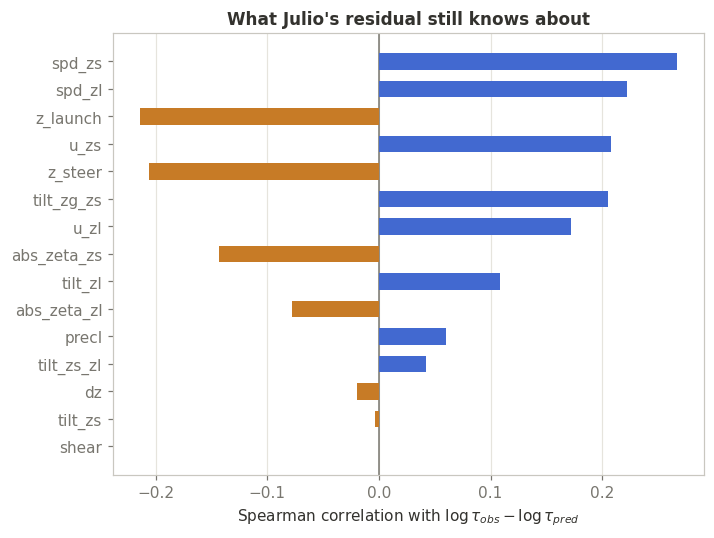

In [8]:
fig, ax = plt.subplots(figsize=(6.6, 5.0))
names_s = [k for _, _, k in screen][::-1]
vals_s = [s for _, s, _ in screen][::-1]
ypos = np.arange(len(names_s))

# Colour encodes only the sign -- which way the model is wrong. Magnitude is
# already carried by bar length; a ramp on top of it would say nothing new.
ax.barh(ypos, vals_s, height=0.6, zorder=3,
        color=[BLUE if v > 0 else AMBER for v in vals_s])
ax.axvline(0, color=MUTED, lw=1)
ax.set(yticks=ypos, yticklabels=names_s,
       xlabel='Spearman correlation with $\\log\\tau_{obs} - \\log\\tau_{pred}$',
       title="What Julio's residual still knows about")
ax.grid(axis='y', visible=False)
plt.tight_layout()

`spd_zs`, the steering-level wind speed, is the biggest single omission
(Spearman +0.27) — physically reasonable, since flux from a moving source should
scale with how fast the flow carries it. `precl` and `tilt_zs` sit near zero,
exactly as they should: the fit has already taken what they had.

The obvious move is to hand PySR the wind speeds. Whether that is right turns out
to depend entirely on what you fit to.

## 4. The transfer test, and what it actually shows

`nn_gwsrc.py` trains a reference MLP per feature set and scores it on a held-out
time block in each hemisphere. The NN is not a deliverable — it is an instrument
for asking "how much skill exists with this feature set?", the role Grundner et
al. (2024) give their NNs before doing equation discovery.

Each set is trained twice:

- **SH only** — the NH is then unseen in *space as well as time*, a true transfer
  test.
- **Both hemispheres** — the NH is unseen in time only.

`R²` is reported alongside `r` deliberately. `r` is blind to an affine
rescaling; CAM needs the magnitude, not just the ranking. `R²cal` is `R²` after
the best affine correction, which separates two very different failures: a model
that recovers under `R²cal` transferred its *function* and only lost its
calibration, fixable with two numbers.

In [9]:
with open('pysr_outputs/nn_reference.json') as f:
    nn = json.load(f)

for regime, title in (('sh', 'TRAINED ON SH ONLY — NH is a genuine transfer test'),
                      ('both', 'TRAINED ON BOTH — NH is held-out times only')):
    print(f'\n{title}')
    print(f'{"feature set":18s} {"n":>3} {"SH r":>7} {"SH R2":>8} {"NH r":>7} '
          f'{"NH R2":>8} {"NH R2cal":>9} {"NH slope":>9}')
    for k, v in nn.items():
        if v['train_on'] != regime:
            continue
        sh_r = v['r_sh'] if regime == 'both' else v['r_test']
        sh_r2 = v['R2_sh'] if regime == 'both' else v['R2_test']
        print(f'{k.split(" [")[0]:18s} {v["n_features"]:3d} {sh_r:7.3f} '
              f'{sh_r2:+8.3f} {v["r_nh"]:7.3f} {v["R2_nh"]:+8.3f} '
              f'{v["R2_nh_cal"]:+9.3f} {v["slope_nh"]:9.2f}')


TRAINED ON SH ONLY — NH is a genuine transfer test
feature set          n    SH r    SH R2    NH r    NH R2  NH R2cal  NH slope
D,P only             2   0.576   +0.332   0.595   +0.193    +0.353      0.87
tilt family          5   0.640   +0.406   0.708   +0.323    +0.501      0.84
+winds,vorticity    10   0.771   +0.592   0.592   -0.161    +0.351      0.74
everything          15   0.782   +0.609   0.574   -0.103    +0.329      0.78
pysr eight           8   0.758   +0.572   0.578   -0.320    +0.334      0.68

TRAINED ON BOTH — NH is held-out times only
feature set          n    SH r    SH R2    NH r    NH R2  NH R2cal  NH slope
D,P only             2   0.572   +0.314   0.652   +0.423    +0.425      0.94
tilt family          5   0.635   +0.387   0.708   +0.495    +0.501      0.91
+winds,vorticity    10   0.757   +0.562   0.743   +0.545    +0.552      0.91
everything          15   0.775   +0.588   0.761   +0.571    +0.578      0.93
pysr eight           8   0.740   +0.527   0.734   +0.534

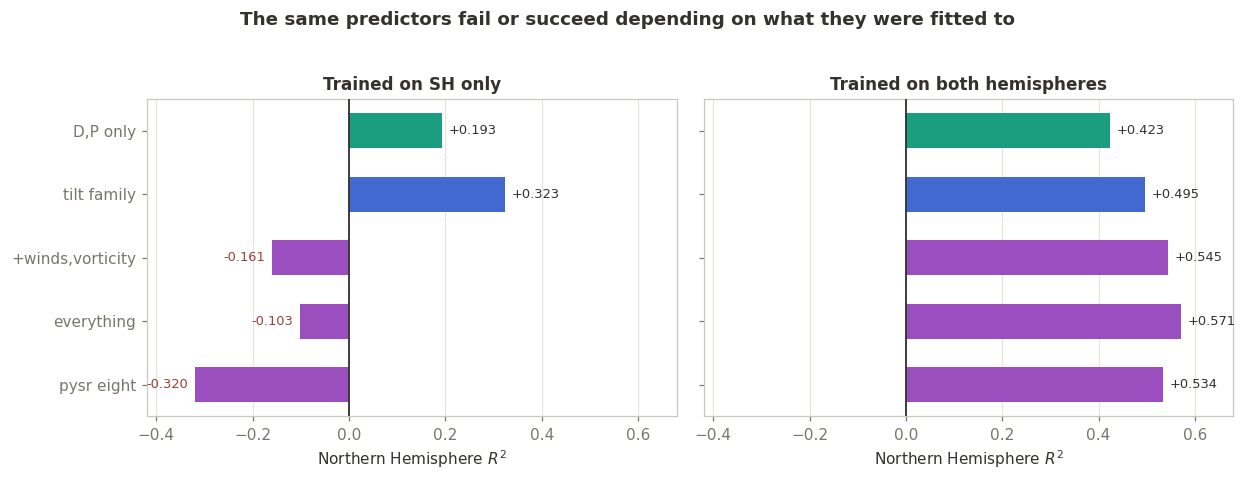

In [10]:
sets = [k.split(' [')[0] for k in nn if nn[k]['train_on'] == 'sh']
ypos = np.arange(len(sets))[::-1]
cols = [TEAL if s == 'D,P only' else BLUE if s == 'tilt family' else PURPLE
        for s in sets]

fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)
for ax, regime, title in ((axs[0], 'sh', 'Trained on SH only'),
                          (axs[1], 'both', 'Trained on both hemispheres')):
    vals = [nn[f'{s} [{regime}]']['R2_nh'] for s in sets]
    ax.barh(ypos, vals, height=0.55, color=cols, zorder=3)
    ax.axvline(0, color=INK, lw=1.2, zorder=4)
    ax.set(xlim=(-0.42, 0.68), xlabel='Northern Hemisphere $R^2$', title=title)
    ax.grid(axis='y', visible=False)
    for yp, v in zip(ypos, vals):
        ax.text(v + (0.014 if v >= 0 else -0.014), yp, f'{v:+.3f}', va='center',
                ha='left' if v >= 0 else 'right', fontsize=8.5,
                color='#9c3d3d' if v < 0 else INK)

axs[0].set(yticks=ypos, yticklabels=sets)
fig.suptitle('The same predictors fail or succeed depending on what they were '
             'fitted to', y=1.03, fontsize=12, color=INK, fontweight='semibold')
plt.tight_layout()

Left panel, SH-only: every set containing winds or heights has a **negative NH
R²** — worse than predicting the mean — while the tilt family stays positive.
That looks like a clean verdict against the winds, and it is the failure Julio's
own `compare_models` docstring names:

> If it fits SH better and transfers worse, it has absorbed the frontal
> collinearity of the SH sample and the six-parameter form is the honest one.

But `R²cal` qualifies it. After an optimal affine correction the wind sets
recover to ~0.33–0.35 — no worse than plain $(D,P)$ at 0.35, though still well
behind the tilt family's 0.50. So they are not structurally broken in the NH;
they simply carry no transferable *extra* information when fitted to one
hemisphere.

Right panel: train on both hemispheres and the picture inverts. NH R² is strongly
positive everywhere and rises monotonically with predictor count, 0.42 → 0.50 →
0.55 → 0.57, with calibration slopes near 0.92. The winds were never the problem;
fitting a global parameterization to a single hemisphere was.

### How the splits are built, and what they cannot tell us

Every split here is on **contiguous time blocks**, applied identically in both
hemispheres — a timestep is entirely in one split on both sides of the equator,
so nothing leaks:

| split | timesteps | days |
|---|---|---|
| train | 0–148 | 18.6 |
| val | 149–172 | 3.0 |
| test | 173–246 | 9.4 |

Three limits worth carrying forward, because they bound how hard the numbers
above can be pushed:

1. **The two NH columns answer different questions.** Trained on SH, the NH is
   unseen in space *and* time — a real transfer test. Trained on both, the NH is
   unseen in time only. The jump from −0.16 to +0.55 is therefore part genuine
   fix and part easier exam, and reading it as a pure improvement overstates the
   case. Global training demonstrably removes a failure mode; it does not
   demonstrate that wind predictors would survive a genuinely held-out region.

2. **This is one month.** 247 three-hourly steps of DYAMOND August 2016. The test
   block is the last 9.4 days of a single August, and the SH and NH test blocks
   are *simultaneous* — they share whatever synoptic regime occupied those days.
   There is no seasonal or interannual holdout anywhere in this notebook.

3. **The effective sample size is far below 4.26M.** The fields are smoothed over
   σ = 2 gridpoints and correlated on synoptic scales, so neighbouring columns are
   not independent draws. Differences of ~0.01 in r should not be read as
   meaningful, whatever the nominal sample count suggests.

## 5. The PySR search

Settings follow the tuning notes in `pysrtips_bety260326.py`:

- **Fit $\log\tau$**, matching the metric and conditioning a 4.5-decade target.
- **Scale inputs to O(1)–O(10)** by a reference near each median; `D_REF` and
  `P_REF` are Julio's, so coefficients stay comparable.
- **Floor `precl`** at $10^{-4}P_{\rm ref}$ — it reaches $10^{-19}$ in dry
  columns, and one such point detonates any `log(P)` in a batch.
- **`complexity_of_variables=2` vs `complexity_of_constants=1`.** The tips note
  the right value depends on the variable count, which is why the sets here are
  capped at eight.
- **Nested constraints** on `^`/`exp`/`log`, and `constraints={"^": (-1,1)}`.
- **`batching=True, batch_size=1000`** — required above ~$10^4$ points.

### Which scaling? Test it rather than assume it

The tips warn that scaling changes the *form* the search finds, not just its
score. `scaling_experiment.py` runs the same budget three ways.

In [11]:
with open('pysr_outputs/scaling_experiment.json') as f:
    sc = json.load(f)
for k, v in sc['results'].items():
    b = v['best']
    print(f'{k:7s} best r_test = {b["r_test"]:.4f}  (complexity {b["complexity"]})')
    print(f'        {b["equation"][:100]}')

ratio   best r_test = 0.7032  (complexity 27)
        log(sqrt((((Us * (Us * 0.46117574)) * (square(Dg) + P)) + Dg) * Dl)) + (Zs * -0.23991048)
zscore  best r_test = 0.6916  (complexity 28)
        ((Us + P) + ((((Dl - ((Zs * 0.75002474) - Dg)) + Us) + (D * 0.32030994)) + 0.20148703)) * 0.23104945
log     best r_test = 0.6905  (complexity 24)
        (Dg + ((Dl + (Us * exp((Ul + (P + Ul)) * 0.17956063))) / 1.1525531)) / 1.7850467


Ratio scaling wins, and the *reason* is visible in the equations: the z-scored
run returns a purely additive expression with no power law anywhere. Sending a
strictly-positive variable negative removes $x^a$ from the reachable space, which
is exactly the failure the tips describe. Physics and measurement agree here.

### Results

Each run writes `pysr_outputs/front_<mode>.json` — every Pareto-front member,
scored on the training block, the held-out time block, and the NH. Reading the
whole front is the point; `get_best()` is a heuristic, not an answer.

```bash
# fitted to SH only -- the transfer experiment
qsub -v MODE=dp,NITER=2000   submit_pysr.pbs          # control, stalls at 0.58
qsub -v MODE=tilt,NITER=2000 submit_pysr.pbs          # transfer-safe set

# fitted to both hemispheres -- the configuration to take seriously
qsub -v MODE=full,NITER=2000,PYSR_TRAIN=both,RUN_TAG=_both submit_pysr.pbs
qsub -v MODE=tilt,NITER=2000,PYSR_TRAIN=both,RUN_TAG=_both submit_pysr.pbs
```

In the `_both` runs the `r_nh` column is held-out *times* in the NH; in the
SH-only runs it is a full transfer test. Same column name, different question —
see the caveats above.

In [12]:
STYLE = {'dp':        (TEAL,   'PySR $(D,P)$, SH-fit — control'),
         'tilt':      (BLUE,   'PySR tilt family, SH-fit'),
         'full':      (PURPLE, 'PySR 8 predictors, SH-fit'),
         'dp_both':   (TEAL,   'PySR $(D,P)$, global fit'),
         'tilt_both': (BLUE,   'PySR tilt family, global fit'),
         'full_both': (PURPLE, 'PySR 8 predictors, global fit')}
DASHED = {'dp_both', 'tilt_both', 'full_both'}   # global fits drawn dashed

# Prefer the full-length PBS result; fall back to a shorter local run so the
# notebook is readable while the long searches are still going.
fronts, run_dirs = {}, {}
for tag in STYLE:
    for suffix in ('', '_prelim'):
        path = f'pysr_outputs/front_{tag}{suffix}.json'
        if os.path.exists(path):
            with open(path) as f:
                fronts[tag] = json.load(f)
            run_dirs[tag] = f'pysr_outputs/gwsrc_{tag}{suffix}'
            if suffix:
                print(f'{tag}: using preliminary run — full search still going')
            break
    else:
        print(f'{tag}: no front yet, run not finished or not submitted')

for tag, fr in fronts.items():
    print(f'\n=== {tag}   features: {", ".join(fr["names"])}')
    print(f'{"cx":>3} {"r_train":>8} {"r_test":>8} {"r_nh":>8}  equation')
    for r in fr['rows']:
        print(f'{r["complexity"]:3d} {r["r_train"]:8.4f} {r["r_test"]:8.4f} '
              f'{r["r_nh"]:8.4f}  {r["equation"][:84]}')

full: no front yet, run not finished or not submitted

=== dp   features: D, P
 cx  r_train   r_test     r_nh  equation
  1   0.0000  -0.0000   0.0000  0.06958383
  3   0.4680   0.4670   0.2286  log(D)
  4   0.4680   0.4670   0.2286  log(sqrt(D))
  5   0.4539   0.4621   0.2444  log(D - -0.29169232)
  6   0.4712   0.4525   0.1831  1.3733722 - (D ^ -0.5535662)
  7   0.5543   0.5525   0.6672  log(sqrt(D + P))
  8   0.5489   0.5552   0.6898  sqrt(P + D) - 1.2017018
  9   0.5648   0.5656   0.6142  (P + log(square(D))) * 0.26568806
 10   0.5788   0.5684   0.5483  sqrt(P + 0.9780984) - (D ^ -0.48858845)
 11   0.5800   0.5678   0.5230  ((P + 1.0329045) ^ 0.46567714) - (D ^ -0.4893741)
 12   0.5819   0.5714   0.5685  log((P + 1.8708149) / (0.81042403 - (-1.0547774 / D)))
 13   0.5823   0.5736   0.5751  (((P + 0.9376644) ^ 0.28121468) - (D ^ -0.27364686)) / 0.49896362
 15   0.5824   0.5736   0.5788  log((P + 1.8672011) / ((D ^ -0.17937228) - (-0.90026677 / D)))
 17   0.5828   0.5732   0.5747  lo

/glade/derecho/scratch/wchapman/tmp/ipykernel_72945/2129323673.py:9: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot([r['complexity'] for r in fr['rows']],


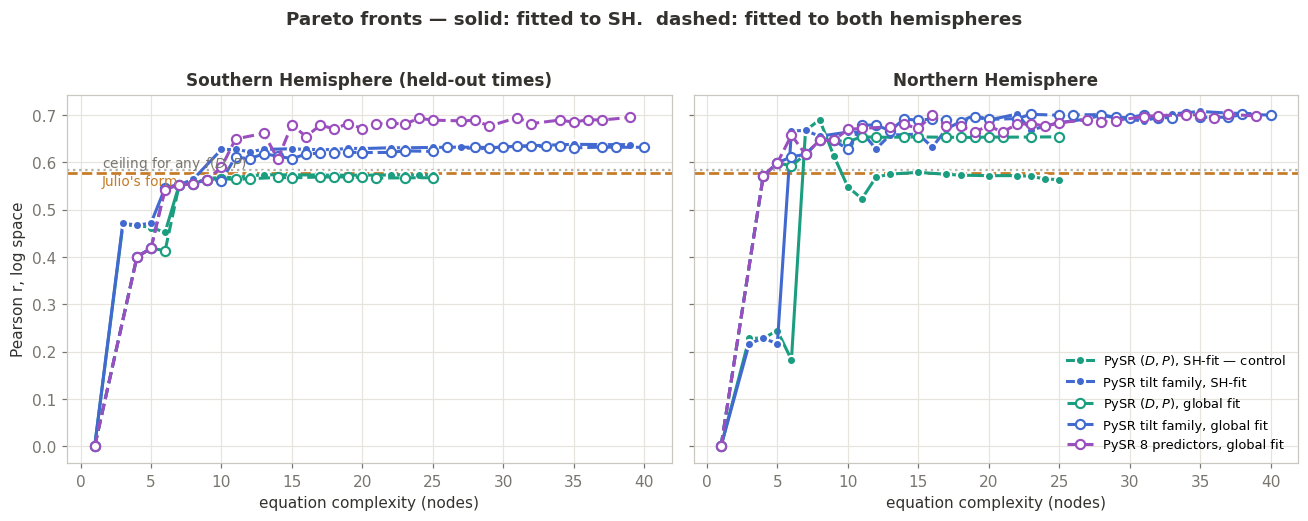

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)

for ax, key, title in ((ax1, 'r_test', 'Southern Hemisphere (held-out times)'),
                       (ax2, 'r_nh', 'Northern Hemisphere')):
    ax.axhline(R_CEIL, color=FAINT, lw=1.5, ls=':', zorder=1)
    ax.axhline(r_baseline, color=AMBER, lw=1.8, ls='--', zorder=2)
    for tag, fr in fronts.items():
        color, label = STYLE[tag]
        ax.plot([r['complexity'] for r in fr['rows']],
                [r[key] for r in fr['rows']], '-o', color=color, lw=2, ms=6,
                ls='--' if tag in DASHED else '-',
                mfc=color if tag not in DASHED else 'white', mec=color
                if tag in DASHED else 'white', mew=1.4, zorder=3, label=label)
    ax.set(xlabel='equation complexity (nodes)', title=title)

ax1.set_ylabel('Pearson r, log space')
ax1.text(1.5, R_CEIL + 0.006, 'ceiling for any $f(D,P)$', color=MUTED, fontsize=9)
ax1.text(1.5, r_baseline - 0.028, "Julio's form", color=AMBER, fontsize=9)
ax2.legend(loc='lower right', fontsize=8.5)
fig.suptitle('Pareto fronts — solid: fitted to SH.  dashed: fitted to both '
             'hemispheres', y=1.02, fontsize=12, color=INK, fontweight='semibold')
plt.tight_layout()

### Picking from the front

Take the smallest complexity within 0.002 of the best held-out score — the elbow,
not the endpoint.

In [14]:
def elbow(rows, tol=0.002):
    best = max(r['r_test'] for r in rows)
    return min((r for r in rows if r['r_test'] >= best - tol),
               key=lambda r: r['complexity'])

picks = {t: elbow(fr['rows']) for t, fr in fronts.items()}
print(f'{"run":>10} {"fit":>6} {"cx":>3} {"train":>7} {"SH":>7} {"NH":>7}  equation')
print(f'{"Julio":>10} {"sh":>6} {"7p":>3} {r_baseline:7.4f} {"":>7} {"":>7}  '
      'y0 + A D^a/(1+D/D0) + B P^b D^c')
for tag, p in picks.items():
    # 'sh' fits score NH as a true transfer test; 'both' fits score it on
    # held-out times only. Label it so the columns are not read as equivalent.
    print(f'{tag:>10} {fronts[tag].get("train_on", "sh"):>6} {p["complexity"]:3d} '
          f'{p["r_train"]:7.4f} {p["r_test"]:7.4f} {p["r_nh"]:7.4f}  '
          f'{p["equation"][:70]}')

       run    fit  cx   train      SH      NH  equation
     Julio     sh  7p  0.5784                  y0 + A D^a/(1+D/D0) + B P^b D^c
        dp     sh  13  0.5823  0.5736  0.5751  (((P + 0.9376644) ^ 0.28121468) - (D ^ -0.27364686)) / 0.49896362
      tilt     sh  33  0.6649  0.6360  0.7020  log(((((P ^ 1.1854795) + 0.23424779) / (square(Dg / (D / Dg)) + 0.5310
   dp_both   both  14  0.6352  0.5681  0.6532  log(((0.050437897 + D) ^ 0.60304147) + ((P ^ 1.2434797) * 0.40714237))
 tilt_both   both  31  0.6865  0.6342  0.7005  log(sqrt((square((P - -0.10285986) / (((Dg ^ 1.5553287) / (D - (-0.152
 full_both   both  24  0.6955  0.6933  0.6765  log(sqrt((square(P) + (square((Dg * Us) + 0.47459406) * Dl)) / (Zt + 1


### Predicted against observed

A column per final model, a row per hemisphere, all on held-out times. At this
sample size a literal scatter is a solid blob, so the marks are density-shaded —
the same plot, honest at 300k points per panel.

The dashed 1:1 line is what to read. A cloud that hugs it is calibrated; a cloud
tilted off it has the right ranking and the wrong amplitude, which `r` cannot see
and which CAM will feel directly. Compare the NH row across columns: that is the
transfer story in one picture.

In [15]:
from pysr import PySRRegressor

D_REF, P_REF, Y_REF, U_REF, Z_REF, Zeta_REF = 3e-7, 3e-8, 4.68e-3, 10.0, 5000.0, 3e-5

rng = np.random.default_rng(1)
subs, obs, Xall = {}, {}, {}
for hemi in ('sh', 'nh'):
    ti = Z[f'tidx_{hemi}']
    s = np.flatnonzero(ti > np.quantile(Z['tidx_sh'], 0.7))
    subs[hemi] = rng.choice(s, min(300_000, s.size), replace=False)
    gh = lambda k: Z[f'{k}_{hemi}'].astype(np.float64)
    uzs, vzs, uzl, vzl = (gh(k) for k in ('u_zs', 'v_zs', 'u_zl', 'v_zl'))
    Xall[hemi] = {
        'D': gh('tilt_zs') / D_REF, 'Dl': gh('tilt_zl') / D_REF,
        'Dg': gh('tilt_zg_zs') / D_REF, 'Dsl': gh('tilt_zs_zl') / D_REF,
        'P': np.maximum(gh('precl') / P_REF, 1e-4),
        'Us': np.hypot(uzs, vzs) / U_REF, 'Ul': np.hypot(uzl, vzl) / U_REF,
        'Zs': gh('z_steer') / Z_REF, 'Zt': np.abs(gh('zeta_zs')) / Zeta_REF,
    }
    obs[hemi] = np.log(gh('epwp_zl'))[subs[hemi]]

models = [('Julio, 7 parameters', None, AMBER)]
for tag, pick in picks.items():
    if os.path.isdir(run_dirs[tag]):
        models.append((f"PySR {tag}\ncx {pick['complexity']}, "
                       f"{fronts[tag].get('train_on', 'sh')}-fit", tag, PURPLE))

# Reloading a run directory pays Julia deserialisation each time, and the figure
# below asks for every model twice (once per hemisphere). Cache them.
_loaded = {}

def predict_log(tag, hemi):
    # log tau for one model on one hemisphere's held-out sample.
    s = subs[hemi]
    if tag is None:
        g = lambda k: Z[f'{k}_{hemi}'].astype(np.float64)
        return np.log(SF.source_model(g('tilt_zs')[s], g('precl')[s], **PAR_JULIO))
    if tag not in _loaded:
        _loaded[tag] = PySRRegressor.from_file(run_directory=run_dirs[tag])
    X = np.column_stack([Xall[hemi][n][s] for n in fronts[tag]['names']])
    # PySR fitted log(tau/Y_REF); undo the reference to get back to log tau.
    return _loaded[tag].predict(X, index=picks[tag]['index']) + np.log(Y_REF)

print(f'{len(models)} models x 2 hemispheres, '
      f'{subs["sh"].size:,} / {subs["nh"].size:,} points')

Precompiling packages...
    859.1 ms  ✓ DataValueInterfaces
    774.0 ms  ✓ IteratorInterfaceExtensions
    809.2 ms  ✓ UnsafePointers
    768.3 ms  ✓ DataAPI
    673.8 ms  ✓ Scratch
    785.3 ms  ✓ Pidfile
   1036.5 ms  ✓ Requires
    919.8 ms  ✓ Preferences
    620.1 ms  ✓ TableTraits
    653.6 ms  ✓ PrecompileTools
    795.8 ms  ✓ JLLWrappers
   2347.6 ms  ✓ OrderedCollections
   3661.3 ms  ✓ StructUtils
   2276.0 ms  ✓ pixi_jll
   4085.9 ms  ✓ MacroTools
   2294.8 ms  ✓ micromamba_jll
   2425.8 ms  ✓ Tables
    566.2 ms  ✓ StructUtils → StructUtilsTablesExt
   1507.0 ms  ✓ MicroMamba
   8764.2 ms  ✓ Parsers
   6630.5 ms  ✓ JSON
   2438.6 ms  ✓ CondaPkg
  20321.8 ms  ✓ PythonCall
  23 dependencies successfully precompiled in 41 seconds. 30 already precompiled.


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


[ Info: Precompiling SymbolicRegression [8254be44-1295-4e6a-a16d-46603ac705cb](cache misses: target mismatch (2))
Precompiling packages...
    654.5 ms  ✓ Reexport
    770.3 ms  ✓ EnumX
    705.6 ms  ✓ StatsAPI
    768.9 ms  ✓ PositiveFactorizations
    762.2 ms  ✓ Adapt
    755.2 ms  ✓ Tricks
    638.1 ms  ✓ TestItems


    870.3 ms  ✓ Statistics
    676.7 ms  ✓ PtrArrays
    951.9 ms  ✓ DocStringExtensions
    744.0 ms  ✓ Interfaces
    926.3 ms  ✓ ADTypes
   1154.5 ms  ✓ ProgressMeter


   1329.5 ms  ✓ FillArrays
    704.0 ms  ✓ StaticArraysCore
   2001.8 ms  ✓ CommonSubexpressions
   1947.0 ms  ✓ ScientificTypesBase
   1767.4 ms  ✓ Statistics → SparseArraysExt
   1545.9 ms  ✓ AliasTables
   2063.4 ms  ✓ NaNMath
   2098.5 ms  ✓ Missings
   1959.0 ms  ✓ OpenSpecFun_jll
   2798.9 ms  ✓ ConstructionBase
   1872.7 ms  ✓ Adapt → AdaptSparseArraysExt
   2096.7 ms  ✓ DataStructures
   2140.1 ms  ✓ Compat
   3026.7 ms  ✓ IrrationalConstants


...

   3082.1 ms  ✓ SpecialFunctions
    834.0 ms  ✓ ADTypes → ADTypesChainRulesCoreExt
    828.1 ms  ✓ ArrayInterface → ArrayInterfaceChainRulesCoreExt
    840.5 ms  ✓ DifferentiationInterface → DifferentiationInterfaceChainRulesCoreExt
    832.5 ms  ✓ DispatchDoctor → DispatchDoctorChainRulesCoreExt
   3777.2 ms  ✓ StatsBase
   1320.5 ms  ✓ DiffRules
   1804.6 ms  ✓ LogExpFunctions → LogExpFunctionsChainRulesCoreExt
   2076.4 ms  ✓ ChainRulesCore → ChainRulesCoreSparseArraysExt
   1849.2 ms  ✓ SpecialFunctions → SpecialFunctionsChainRulesCoreExt


   7036.6 ms  ✓ DynamicQuantities
    912.0 ms  ✓ DynamicQuantities → DynamicQuantitiesLinearAlgebraExt
   4743.9 ms  ✓ ForwardDiff
   1966.0 ms  ✓ DifferentiationInterface → DifferentiationInterfaceForwardDiffExt
   1053.9 ms  ✓ NLSolversBase
   2292.5 ms  ✓ LineSearches
   3041.2 ms  ✓ Optim
  17410.0 ms  ✓ DynamicExpressions


   1821.8 ms  ✓ DynamicExpressions → DynamicExpressionsOptimExt
   3640.8 ms  ✓ DynamicDiff
  66260.2 ms  ✓ SymbolicRegression
  71 dependencies successfully precompiled in 98 seconds. 41 already precompiled.


[ Info: Precompiling StructUtilsStaticArraysCoreExt [5f8627f4-f0c5-5aac-996c-f7a3cc29134a](cache misses: target mismatch (2))
Precompiling packages...
    660.8 ms  ✓ StructUtils → StructUtilsStaticArraysCoreExt
  1 dependency successfully precompiled in 1 seconds. 6 already precompiled.


6 models x 2 hemispheres, 300,000 / 300,000 points


Attempting to load model from pysr_outputs/gwsrc_dp/checkpoint.pkl...


Attempting to load model from pysr_outputs/gwsrc_tilt/checkpoint.pkl...


Attempting to load model from pysr_outputs/gwsrc_dp_both/checkpoint.pkl...


Attempting to load model from pysr_outputs/gwsrc_tilt_both/checkpoint.pkl...


Attempting to load model from pysr_outputs/gwsrc_full_both/checkpoint.pkl...


Text(0.5, 0.98, 'Predicted against observed — held-out times, both hemispheres')

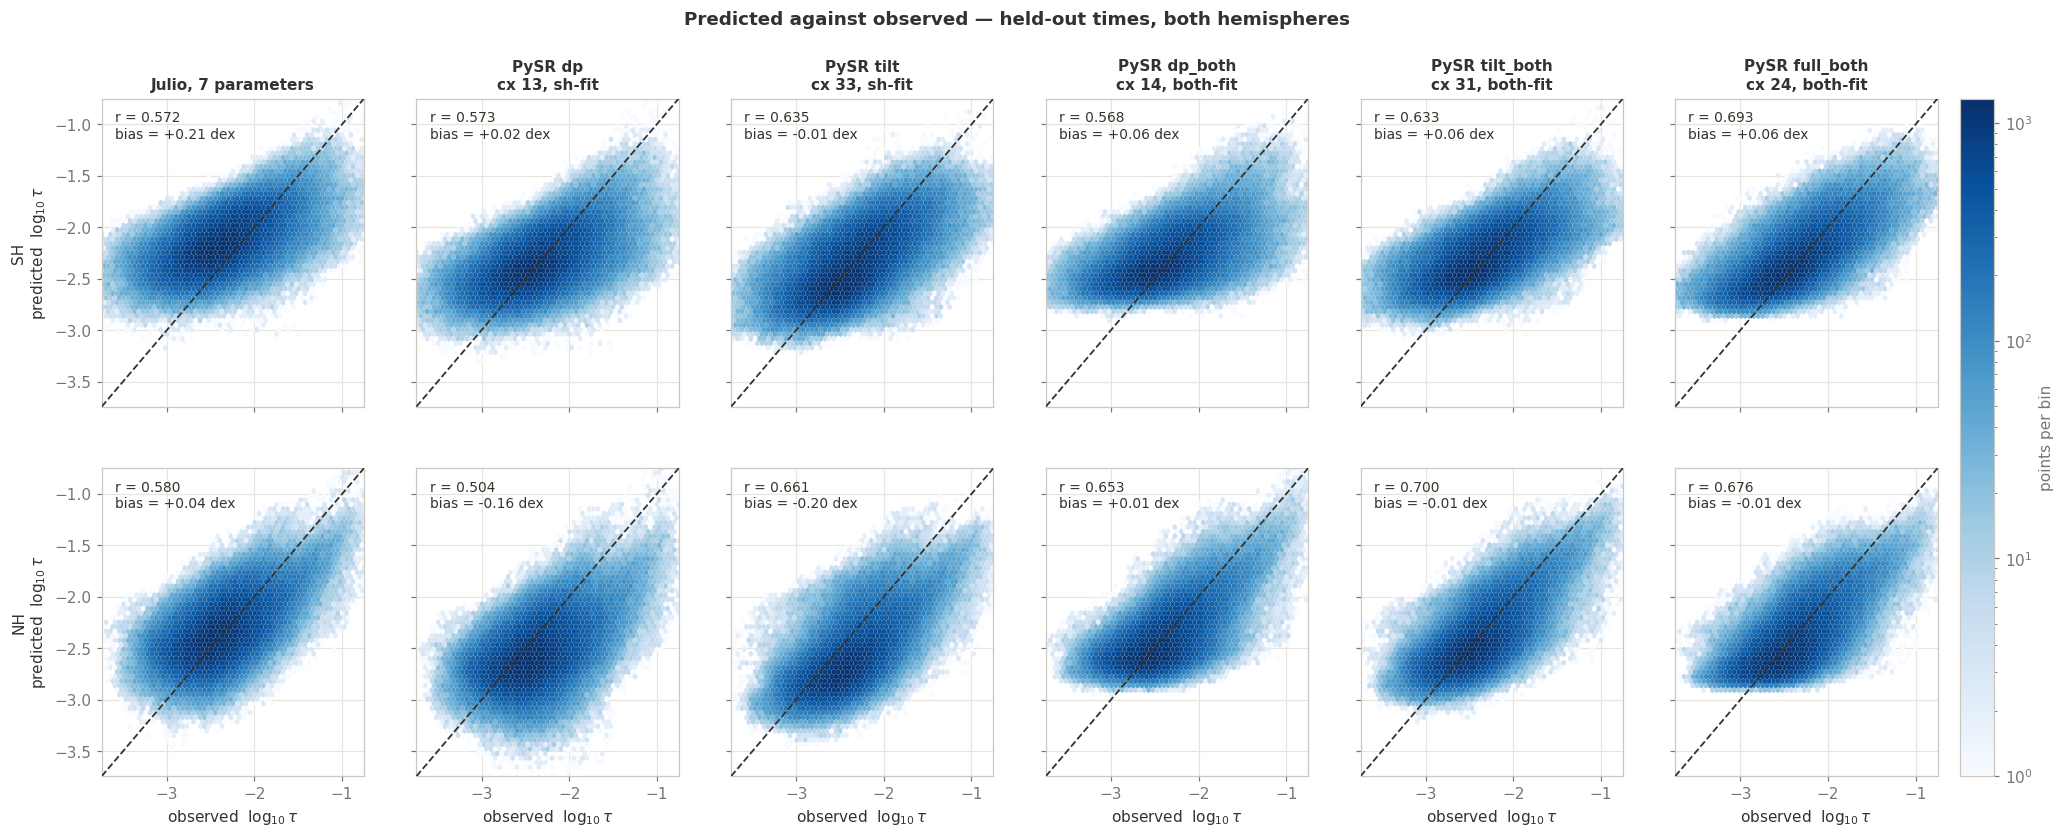

In [16]:
ncol = len(models)
fig, axs = plt.subplots(2, ncol, figsize=(3.7 * ncol, 8.0),
                        sharex=True, sharey=True, squeeze=False)

x_all = np.concatenate([obs['sh'], obs['nh']]) / np.log(10)
lo, hi = np.percentile(x_all, [0.2, 99.8])
lo, hi = lo - 0.15, hi + 0.15

for row, hemi in enumerate(('sh', 'nh')):
    x = obs[hemi] / np.log(10)
    for col, (label, tag, color) in enumerate(models):
        ax = axs[row][col]
        yv = predict_log(tag, hemi) / np.log(10)
        ok = np.isfinite(yv) & np.isfinite(x)
        hb = ax.hexbin(x[ok], yv[ok], gridsize=60, extent=(lo, hi, lo, hi),
                       cmap='Blues', norm=LogNorm(), mincnt=1, linewidths=0)
        ax.plot([lo, hi], [lo, hi], color=INK, lw=1.2, ls='--', zorder=4)
        r = np.corrcoef(x[ok], yv[ok])[0, 1]
        bias = np.median(yv[ok] - x[ok])
        ax.text(0.05, 0.96, f'r = {r:.3f}\nbias = {bias:+.2f} dex',
                transform=ax.transAxes, va='top', fontsize=9, color=INK)
        if row == 0:
            ax.set_title(label, color=INK, fontsize=10)
        ax.set(xlim=(lo, hi), ylim=(lo, hi))
        if row == 1:
            ax.set_xlabel('observed  $\\log_{10}\\tau$')
    axs[row][0].set_ylabel(f'{hemi.upper()}\npredicted  $\\log_{{10}}\\tau$')

cb = fig.colorbar(hb, ax=axs, fraction=0.018, pad=0.012)
cb.set_label('points per bin', color=MUTED)
fig.suptitle('Predicted against observed — held-out times, both hemispheres',
             y=0.98, fontsize=12, color=INK, fontweight='semibold')

## 6. Where this leaves the parameterization

- **Julio's cooked-up form is not improvable as an equation.** It sits within
  0.005 of a form-free bound on $f(D,P)$, confirmed by binned variance
  decomposition, a gradient-boosted tree, an MLP, and PySR itself stalling in the
  same place with the same inputs. Do not spend more compute searching for a
  better $f(D,P)$.
- **The gain is in the predictors.** Steering-level wind speed is the strongest
  single omission by residual correlation, and the tilt family is the most
  reliable addition.
- **Fit globally.** The single biggest methodological finding here is that a
  hemisphere-restricted fit makes wind predictors look actively harmful, and a
  global fit makes them the best available. Both statements come from the same
  data and the same architecture. If a parameterization is going to run
  globally, it has to be fitted that way, and its transfer has to be reported.
- **A short expression captures most of the honest gain.** See the elbow table
  above — the picks beat the hand-built form at a complexity a human can read.
- **What PySR adds over the NN and the GBT** is that the result is an equation
  you can read, differentiate, and put in CAM. Grundner et al. (2024) found the
  same for cloud cover, including that the equation transferred better than the
  network it competed with.

### Before trusting any single equation

The tips in `pysrtips_bety260326.py` are emphatic that small runs do not
extrapolate — new regimes emerge at scale, sometimes with different variables
becoming important. Rerun at `niterations=2000+` and confirm the front is stable
before adopting a form. `submit_pysr.pbs` is set up for that, bounded on wall
clock via `PYSR_TIMEOUT` so the search always returns its hall of fame.

Three further steps worth taking:

1. **Fix the calibration.** Every model here, Julio's included, has a non-zero
   median bias in the scatter panels. `r` cannot see it and CAM cannot ignore it.
   The affine diagnostic in `nn_gwsrc.metrics` is the cheap version of the check.
2. **Get a second month.** Every generalization claim here rests on the last 9.4
   days of one August, with the SH and NH test blocks simultaneous. A DYAMOND
   winter case would turn "held-out times" into something worth the name.
3. **Test a genuinely held-out region.** The global fits are validated on unseen
   times, not unseen space. Holding out a latitude band, or the tropics, would
   test whether the wind predictors carry physics or geography.